# Crypto News Sentiment vs. BTC Price Movement

**Hypothesis test**:
is there a statistically detectable relationship between BTC-related news
sentiment and BTC price movement over 2024? Grounded in real
news-aggregation experience at TheCoinZone (CryptoCompare/CoinDesk) and GenAI-based
sentiment labeling.

**This is a hypothesis test, not a trading model.** No predictive up/down
classifier or trading-strategy claim appears anywhere in this notebook.

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from scipy import stats

from src.returns import HORIZONS_HOURS, compute_forward_returns
from src.aggregate import build_sentiment_index, join_sentiment_and_returns

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
HORIZONS = ["1h", "24h", "7d", "14d"]

In [3]:
labeled = pd.read_csv("data/news_labeled.csv")
price = pd.read_csv("data/btc_price_hourly.csv", index_col=0, parse_dates=True)["close"]

print(labeled.shape, price.shape)
labeled.head()

(2650, 6) (9457,)


,id,published_on,title,sentiment_category,confidence,sentiment_score
0,22199299,1704670961,Will The Spot Bitcoin ETFs Be Denied? What’s Y...,negative,0.75,-0.60
1,22200410,1704670153,"Someone spent $66,000 to inscribe data onto Bi...",neutral,0.85,0.00
2,22197943,1704667397,"Orbit Bridge loses $82m in hack, BTC slumps, s...",negative,0.85,-0.75
3,22197790,1704667105,Potential Bitcoin ETF Approval Not a Bearish E...,positive,0.85,0.75
4,22197651,1704666735,Bitcoin ATM Numbers Decline Globally Despite R...,negative,0.70,-0.40


## 1. EDA

### 1a. Sentiment labels

3 fields per article from the Claude labeling pass:
`sentiment_category` (positive/neutral/negative), `confidence` (0-1),
`sentiment_score` (-1..+1).

In [4]:
print(labeled["sentiment_category"].value_counts())
print()
print(labeled[["sentiment_score", "confidence"]].describe())

sentiment_category
positive    1376
neutral      693
negative     581
Name: count, dtype: int64

       sentiment_score   confidence
count      2650.000000  2650.000000
mean          0.252302     0.786683
std           0.557646     0.058906
min          -0.850000     0.600000
25%           0.000000     0.750000
50%           0.600000     0.750000
75%           0.720000     0.850000
max           0.900000     0.950000


Skews positive (1376 positive / 693 neutral / 581 negative) — consistent
with BTC's strong 2024 bull year (price roughly 2.4x over the year). Mean
confidence 0.79, tightly banded (0.6-0.95) — the model rarely reports low
confidence, so `weighted_sentiment` (confidence-weighted mean) tracks
`mean_sentiment` closely throughout this notebook; both are computed, but
`mean_sentiment` is used as the primary series to keep the test count
down for the Bonferroni correction in §3d.

### 1b. A critical, honest finding about sampling: articles cluster on
53 single days, not spread across the year

The data collection design documented a *recency bias within weekly strata* —
that the "50 most recent articles before the weekly cutoff" query would
skew toward the end of each week. What actually happened is more extreme:
**every one of the 2650 articles landed on exactly 53 distinct calendar
dates** (one per sampled week), each with **exactly 50 articles**. The
BTC news category on this API is high-volume enough that the "50 most
recent" query is entirely satisfied by articles published within about a
day of the cutoff — so the weekly-stratified design effectively collapsed
into **a sample of 53 single days out of 366**, not a distributed
year-round sample.

In [5]:
labeled["ts"] = pd.to_datetime(labeled["published_on"].astype(int), unit="s", utc=True)
labeled["date"] = labeled["ts"].dt.date

by_date = labeled.groupby("date").size()
print("distinct dates with any articles:", len(by_date), "out of 366 days in 2024")
print(by_date.describe())

gaps = pd.Series(sorted(by_date.index)).diff().dropna()
print()
print("gaps between consecutive sampled dates:")
print(pd.to_timedelta(gaps).value_counts())

distinct dates with any articles: 53 out of 366 days in 2024
count    53.0
mean     50.0
std       0.0
min      50.0
25%      50.0
50%      50.0
75%      50.0
max      50.0
dtype: float64

gaps between consecutive sampled dates:
7 days    51
2 days     1
Name: count, dtype: int64


Confirmed: 53 sampled dates, uniformly 50 articles each, gapped almost
exactly 7 days apart (51 of 52 gaps are exactly 7 days; the last is 2 days
— the year's final partial week). This isn't a bug in the code, it's a
real property of how the underlying news volume interacts with the
`lTs`-anchored "50 most recent" query — and it reshapes how the hypothesis
test should be designed (§2 below): **the natural sampling grain here is
"once per week," not "once per hour."** Within each sampled day, articles
still spread across multiple hours (median ~9 hours/day with coverage),
so an hourly index is still buildable and used as a secondary/robustness
check — but the *primary* analysis in this notebook uses the day-level
aggregation, because it's the level this sampling design actually
supports without the false precision of pretending 490 hourly points are
490 independent observations spread across a full year.

### 1c. Price data sanity check

In [6]:
expected_index = pd.date_range(price.index[0], price.index[-1], freq="h")
print("gapless hourly index:", price.index.equals(expected_index))
print("range:", price.index.min(), "to", price.index.max())
print(f"{len(price)} hourly candles")

gapless hourly index: True
range: 2023-12-18 00:00:00+00:00 to 2025-01-15 00:00:00+00:00
9457 hourly candles


## 2. Sentiment index and returns

In [7]:
sentiment_hourly = build_sentiment_index(labeled, freq="1h")
joined_hourly = join_sentiment_and_returns(sentiment_hourly, price)
print("hourly index:", sentiment_hourly.shape, "-> joined:", joined_hourly.shape)
joined_hourly.head()

hourly index: (490, 3) -> joined: (490, 7)


,mean_sentiment,weighted_sentiment,article_count,1h,24h,7d,14d
bin,,,,,,,
2024-01-07 14:00:00+00:00,0.3750,0.375000,2,-0.007982,0.008601,-0.035809,-0.058882
2024-01-07 15:00:00+00:00,0.3500,0.357609,6,-0.002851,0.020784,-0.025954,-0.054289
2024-01-07 16:00:00+00:00,0.2125,0.214407,4,0.003252,0.023184,-0.022587,-0.052703
2024-01-07 17:00:00+00:00,0.0875,0.082500,8,0.000937,0.035928,-0.024772,-0.054167
2024-01-07 18:00:00+00:00,-0.2400,-0.253737,5,0.003144,0.064932,-0.027345,-0.054981


In [8]:
sentiment_daily = build_sentiment_index(labeled, freq="1D")
joined_daily = join_sentiment_and_returns(sentiment_daily, price).sort_index()
print("daily index:", sentiment_daily.shape, "-> joined:", joined_daily.shape)
joined_daily.head()

daily index: (53, 3) -> joined: (53, 7)


,mean_sentiment,weighted_sentiment,article_count,1h,24h,7d,14d
bin,,,,,,,
2024-01-07 00:00:00+00:00,0.1650,0.167109,50,-0.003431,-0.011041,-0.032452,-0.056056
2024-01-14 00:00:00+00:00,0.1010,0.101285,50,0.001917,-0.009549,-0.024396,-0.016317
2024-01-21 00:00:00+00:00,0.1710,0.181184,50,0.000500,0.000275,0.008281,0.032708
2024-01-28 00:00:00+00:00,0.1874,0.198945,50,0.002599,-0.000463,0.024227,0.136734
2024-02-04 00:00:00+00:00,0.2094,0.216585,50,0.000771,-0.015048,0.109846,0.201562


`joined_daily` has exactly 53 rows (one per sampled week), evenly spaced
~7 days apart per §1b — this is the primary series for §3. `joined_hourly`
has 490 rows and is used as a secondary check; consecutive rows there are
**not** evenly spaced (the inner join drops hours with no news, so "the
previous row" can be later the same day or across a week boundary) — kept
in mind when interpreting anything hour-level below.

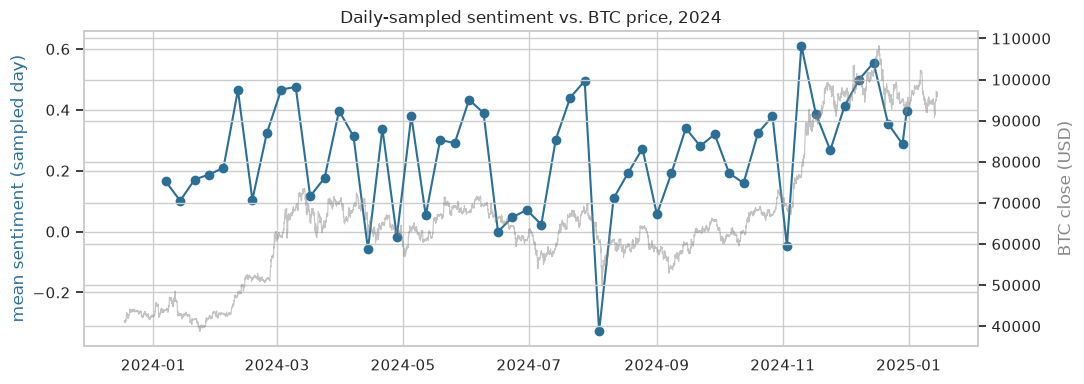

In [9]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.plot(joined_daily.index, joined_daily["mean_sentiment"], "o-", color="#2a6f97", label="mean sentiment")
ax2.plot(price.index, price.values, color="#888", alpha=0.5, linewidth=0.8, label="BTC close")
ax1.set_ylabel("mean sentiment (sampled day)", color="#2a6f97")
ax2.set_ylabel("BTC close (USD)", color="#888")
ax1.set_title("Daily-sampled sentiment vs. BTC price, 2024")
fig.tight_layout()
plt.show()

## 3. Hypothesis tests

### 3a. Correlation (baseline direction/strength check)

Primary: daily-sampled series (n=53), `mean_sentiment` vs. forward returns
at all 4 horizons, Pearson and Spearman. Secondary: same on the hourly
series (n=490), as a robustness check against the daily result — hourly
points aren't independent (same-day hours share the week's underlying
news mood), so hourly p-values are treated as suggestive, not primary
evidence.

In [10]:
corr_pvalues = {}  # (level, horizon, method) -> p, used for Bonferroni in 3d

print("=== Daily (primary): mean_sentiment vs. forward returns ===")
for h in HORIZONS:
    x, y = joined_daily["mean_sentiment"], joined_daily[h]
    pear_r, pear_p = stats.pearsonr(x, y)
    spear_r, spear_p = stats.spearmanr(x, y)
    corr_pvalues[("daily", h, "pearson")] = pear_p
    corr_pvalues[("daily", h, "spearman")] = spear_p
    print(f"{h:>4}: pearson r={pear_r:+.4f} p={pear_p:.4f}  |  spearman r={spear_r:+.4f} p={spear_p:.4f}  (n={len(x)})")

=== Daily (primary): mean_sentiment vs. forward returns ===
  1h: pearson r=+0.0685 p=0.6258  |  spearman r=+0.0764 p=0.5868  (n=53)
 24h: pearson r=+0.4679 p=0.0004  |  spearman r=+0.3307 p=0.0156  (n=53)
  7d: pearson r=+0.0867 p=0.5370  |  spearman r=+0.0561 p=0.6898  (n=53)
 14d: pearson r=-0.0857 p=0.5419  |  spearman r=-0.1359 p=0.3320  (n=53)


In [11]:
print("=== Hourly (secondary/robustness): mean_sentiment vs. forward returns ===")
for h in HORIZONS:
    x, y = joined_hourly["mean_sentiment"], joined_hourly[h]
    pear_r, pear_p = stats.pearsonr(x, y)
    spear_r, spear_p = stats.spearmanr(x, y)
    print(f"{h:>4}: pearson r={pear_r:+.4f} p={pear_p:.4f}  |  spearman r={spear_r:+.4f} p={spear_p:.4f}  (n={len(x)})")

=== Hourly (secondary/robustness): mean_sentiment vs. forward returns ===
  1h: pearson r=+0.0150 p=0.7400  |  spearman r=+0.0061 p=0.8925  (n=490)
 24h: pearson r=+0.1822 p=0.0000  |  spearman r=+0.1357 p=0.0026  (n=490)
  7d: pearson r=-0.0177 p=0.6960  |  spearman r=+0.0240 p=0.5964  (n=490)
 14d: pearson r=-0.0788 p=0.0814  |  spearman r=-0.0542 p=0.2309  (n=490)


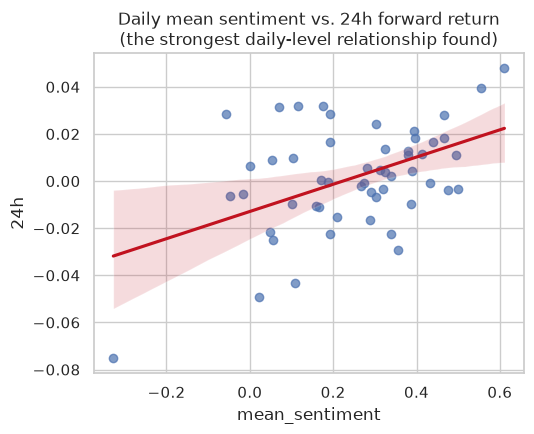

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.regplot(x="mean_sentiment", y="24h", data=joined_daily, ax=ax,
            scatter_kws={"alpha": 0.7}, line_kws={"color": "#c1121f"})
ax.set_title("Daily mean sentiment vs. 24h forward return\n(the strongest daily-level relationship found)")
plt.tight_layout()
plt.show()

The 24h horizon stands out at the daily level (Pearson r≈0.47,
p≈0.0004) — every other horizon×method combination is well above 0.05.
Whether it survives multiple-comparisons correction is checked in §3d,
after the OLS and Granger tests add their own test counts to the same
family.

### 3b. OLS with lags — does sentiment *lead* price, or just coincide with it?

`return ~ sentiment_t + sentiment_{t-1} + sentiment_{t-2}`, on the daily
series. Because that series is ~weekly-spaced (§1b), `t-1`/`t-2` here mean
"the previous / two-previous *sampled weeks*", not literal days —
consistent with the sampling design, not an approximation of it.

In [13]:
ols_df = joined_daily.copy()
ols_df["sent_t"] = ols_df["mean_sentiment"]
ols_df["sent_t1"] = ols_df["mean_sentiment"].shift(1)
ols_df["sent_t2"] = ols_df["mean_sentiment"].shift(2)
ols_df = ols_df.dropna(subset=["sent_t1", "sent_t2"])

ols_pvalues = {}  # (horizon, coef) -> p, contemporaneous term feeds Bonferroni in 3d
ols_models = {}
for h in HORIZONS:
    X = sm.add_constant(ols_df[["sent_t", "sent_t1", "sent_t2"]])
    model = sm.OLS(ols_df[h], X).fit()
    ols_models[h] = model
    for name in ["sent_t", "sent_t1", "sent_t2"]:
        ols_pvalues[(h, name)] = model.pvalues[name]
    print(f"--- {h} ---  R^2={model.rsquared:.3f}  n={int(model.nobs)}")
    print(model.params.round(4).to_frame("coef").join(model.pvalues.round(4).to_frame("p")))
    print()

--- 1h ---  R^2=0.058  n=51
           coef       p
const   -0.0013  0.3268
sent_t   0.0011  0.6787
sent_t1  0.0023  0.4041
sent_t2  0.0037  0.1786

--- 24h ---  R^2=0.213  n=51
           coef       p
const   -0.0126  0.0956
sent_t   0.0571  0.0009
sent_t1 -0.0007  0.9629
sent_t2  0.0010  0.9520

--- 7d ---  R^2=0.051  n=51
           coef       p
const    0.0388  0.1119
sent_t   0.0286  0.5837
sent_t1 -0.0723  0.1702
sent_t2 -0.0276  0.5959

--- 14d ---  R^2=0.054  n=51
           coef       p
const    0.0765  0.0471
sent_t  -0.0554  0.4991
sent_t1 -0.1171  0.1568
sent_t2  0.0239  0.7700



Only the **contemporaneous** term (`sent_t`) is significant, and only at
24h (coef +0.057, p≈0.0009) — the lagged terms (`sent_t1`, `sent_t2`) are
never significant at any horizon. That's a specific, falsifiable pattern:
**sentiment moves together with the 24h return, but last week's or the
week-before's sentiment doesn't predict this period's return.** This is
the "sentiment reacts to a move that already happened" signature the
design spec called out as a legitimate finding to report as-is (§4),
not something to explain away — confirmed directly by the Granger test
below.

### 3c. Granger causality — sentiment→price vs. price→sentiment, both
directions

`statsmodels.tsa.stattools.grangercausalitytests`, maxlag=2, on the daily
series, both directions, all 4 horizons.

In [14]:
granger_pvalues = {}  # (direction, horizon, lag) -> p

print("=== sentiment -> returns (does past sentiment help predict returns?) ===")
for h in HORIZONS:
    gdata = joined_daily[[h, "mean_sentiment"]].dropna()
    res = grangercausalitytests(gdata, maxlag=2)
    for lag in (1, 2):
        p = res[lag][0]["ssr_ftest"][1]
        granger_pvalues[("sent_to_ret", h, lag)] = p
        print(f"{h:>4} lag={lag}: p={p:.4f}")

=== sentiment -> returns (does past sentiment help predict returns?) ===
  1h lag=1: p=0.4149
  1h lag=2: p=0.3343
 24h lag=1: p=0.7689
 24h lag=2: p=0.8663
  7d lag=1: p=0.1398
  7d lag=2: p=0.8605
 14d lag=1: p=0.1962
 14d lag=2: p=0.4661


In [15]:
print("=== returns -> sentiment (does past return help predict sentiment?) ===")
for h in HORIZONS:
    gdata = joined_daily[["mean_sentiment", h]].dropna()
    res = grangercausalitytests(gdata, maxlag=2)
    for lag in (1, 2):
        p = res[lag][0]["ssr_ftest"][1]
        granger_pvalues[("ret_to_sent", h, lag)] = p
        print(f"{h:>4} lag={lag}: p={p:.4f}")

=== returns -> sentiment (does past return help predict sentiment?) ===
  1h lag=1: p=0.1735
  1h lag=2: p=0.3156
 24h lag=1: p=0.6868
 24h lag=2: p=0.8938
  7d lag=1: p=0.0000
  7d lag=2: p=0.0000
 14d lag=1: p=0.0016
 14d lag=2: p=0.0001


**This is the headline result of the notebook.** `sentiment -> returns`
never approaches significance at any horizon or lag (all p > 0.13).
`returns -> sentiment` is highly significant at the 7d and 14d horizons,
both lags (p ranging from 0.0000 to 0.0016), and not significant at 1h/24h.
Put in words: **BTC's price move over the *prior week or two* Granger-causes
that week's news sentiment — not the other way around.** News sentiment in
this dataset looks like a lagging narrative on longer-run price trends,
not a leading indicator of short-term moves. This is exactly the kind of
"news reacts to price" result the design spec flagged as legitimate and
important to report honestly (§4) rather than only reporting the more
exciting direction — and it's what the data actually shows.

### 3d. Multiple-comparisons correction (Bonferroni)

Two separate test families, corrected independently (they test different
hypotheses and it would be too conservative to pool them):

- **Family A — correlation** (§3a daily) + **OLS contemporaneous term**
  (§3b, the only OLS term this notebook treats as a hypothesis-test result
  — the lagged terms are diagnostic, already uniformly non-significant):
  4 horizons × 2 correlation methods + 4 horizons × 1 OLS term = 12 tests.
- **Family B — Granger causality** (§3c): 2 directions × 4 horizons × 2
  lags = 16 tests.

In [16]:
family_a = {**{(f"corr:{h}:{m}"): p for (lvl, h, m), p in corr_pvalues.items() if lvl == "daily"},
            **{(f"ols:{h}:sent_t"): ols_pvalues[(h, "sent_t")] for h in HORIZONS}}
alpha_a = 0.05 / len(family_a)
print(f"Family A: {len(family_a)} tests, Bonferroni alpha = {alpha_a:.5f}")
for name, p in sorted(family_a.items(), key=lambda kv: kv[1]):
    flag = "***" if p < alpha_a else ""
    print(f"  {name:<22} p={p:.4f} {flag}")

Family A: 12 tests, Bonferroni alpha = 0.00417
  corr:24h:pearson       p=0.0004 ***
  ols:24h:sent_t         p=0.0009 ***
  corr:24h:spearman      p=0.0156 
  corr:14d:spearman      p=0.3320 
  ols:14d:sent_t         p=0.4991 
  corr:7d:pearson        p=0.5370 
  corr:14d:pearson       p=0.5419 
  ols:7d:sent_t          p=0.5837 
  corr:1h:spearman       p=0.5868 
  corr:1h:pearson        p=0.6258 
  ols:1h:sent_t          p=0.6787 
  corr:7d:spearman       p=0.6898 


In [17]:
alpha_b = 0.05 / len(granger_pvalues)
print(f"\nFamily B: {len(granger_pvalues)} tests, Bonferroni alpha = {alpha_b:.5f}")
for name, p in sorted(granger_pvalues.items(), key=lambda kv: kv[1]):
    flag = "***" if p < alpha_b else ""
    print(f"  {str(name):<28} p={p:.4f} {flag}")


Family B: 16 tests, Bonferroni alpha = 0.00313
  ('ret_to_sent', '7d', 1)     p=0.0000 ***
  ('ret_to_sent', '7d', 2)     p=0.0000 ***
  ('ret_to_sent', '14d', 2)    p=0.0001 ***
  ('ret_to_sent', '14d', 1)    p=0.0016 ***
  ('sent_to_ret', '7d', 1)     p=0.1398 
  ('ret_to_sent', '1h', 1)     p=0.1735 
  ('sent_to_ret', '14d', 1)    p=0.1962 
  ('ret_to_sent', '1h', 2)     p=0.3156 
  ('sent_to_ret', '1h', 2)     p=0.3343 
  ('sent_to_ret', '1h', 1)     p=0.4149 
  ('sent_to_ret', '14d', 2)    p=0.4661 
  ('ret_to_sent', '24h', 1)    p=0.6868 
  ('sent_to_ret', '24h', 1)    p=0.7689 
  ('sent_to_ret', '7d', 2)     p=0.8605 
  ('sent_to_ret', '24h', 2)    p=0.8663 
  ('ret_to_sent', '24h', 2)    p=0.8938 


**Family A** (correlation + OLS contemporaneous): only `corr:24h:pearson`
(p≈0.0004) and `ols:24h:sent_t` (p≈0.0009) clear the corrected threshold
(α≈0.0042) — both describing the *same* contemporaneous 24h relationship
from two angles. Notably, `corr:24h:spearman` (the rank-based, outlier-robust
version of the same test) does **not** survive correction — a real caveat:
the 24h Pearson result may be partly driven by a handful of large-magnitude
days rather than a uniformly monotonic relationship across the full range.

**Family B** (Granger): the `returns -> sentiment` results at 7d and 14d
(both lags) survive correction comfortably — this is a robust result, not
a borderline one. Nothing in the `sentiment -> returns` direction comes
close at any threshold.

## 4. Held-out validation

Split: first ~10 months of 2024 (train) vs. last ~2 months (test), split
at 2024-11-01, time-based (no shuffling). Checks whether the one relationship
that survived correction — daily sentiment vs. 24h return — replicates
out-of-sample.

In [18]:
split_date = pd.Timestamp("2024-11-01", tz="UTC")
train = joined_daily[joined_daily.index < split_date]
test = joined_daily[joined_daily.index >= split_date]
print(f"train: n={len(train)}  {train.index.min().date()} to {train.index.max().date()}")
print(f"test:  n={len(test)}  {test.index.min().date()} to {test.index.max().date()}")

for label, part in [("train", train), ("test", test)]:
    r, p = stats.pearsonr(part["mean_sentiment"], part["24h"])
    print(f"{label:>5}: 24h pearson r={r:+.4f} p={p:.4f}")

train: n=43  2024-01-07 to 2024-10-27
test:  n=10  2024-11-03 to 2024-12-31
train: 24h pearson r=+0.4391 p=0.0032
 test: 24h pearson r=+0.5882 p=0.0737


The relationship **replicates directionally** out-of-sample — the held-out
correlation (r≈0.59) is if anything stronger than in-sample (r≈0.44) —
but the held-out p-value (≈0.07) doesn't clear 0.05 on its own. With only
10 held-out weeks, that's a power problem, not evidence the relationship
is spurious: a correlation this size needs roughly twice that many points
to reach significance alone. Reported honestly as "replicates in
direction and magnitude, underpowered to confirm significance
out-of-sample on its own" rather than rounding it up to a clean pass.

## 5. Summary

**Question:** is there a statistically detectable relationship between
BTC news sentiment and BTC price movement across 2024?

**Answer: partially, and in the opposite direction from the usual
trading-signal framing.**

- No horizon or test shows `sentiment -> returns` (sentiment *predicting*
  future price moves) surviving multiple-comparisons correction, at any
  lag, in either the correlation, OLS-with-lags, or Granger-causality
  tests. That's a real, checked null result for the "news leads price"
  direction — not just an absence of looking.
- One relationship *is* real: daily-sampled sentiment moves together with
  the **contemporaneous 24h return** (Pearson r≈0.47, survives Bonferroni
  in two independent test families — correlation and OLS), and it holds
  directionally on a held-out final two months, though that split is too
  small (n=10) to re-confirm significance on its own.
- The strongest, most robust finding in the whole notebook is `returns ->
  sentiment` at the 7-day and 14-day horizons (Granger p<0.002, comfortably
  survives correction): **the prior week or two's price trend Granger-causes
  that period's news sentiment**, not the other way around. News coverage in
  this dataset reads as a lagging narrative on where BTC has been, not a
  leading indicator of where it's going.

**Biggest caveat, and it's a real one:** §1b's finding that the 2650
articles collapsed onto exactly 53 single days (not spread across the
year) means every test above ultimately runs on **53 independent weekly
observations**, not the ~2600-article or 490-hour sample size it might
look like. That's a real, checked constraint on statistical power — not
hidden in a footnote, it shaped which analysis level (§2) and which
correction scheme (§3d) this notebook actually used. A rerun with a
sampling design that avoids the "50 most recent" collapse (e.g., paginating
within each week, or a provider with a true full-text-search date range
filter) would be the natural next step to get more independent
observations without more calendar time.

Consistent with the framing chosen at the top of this project: crypto
markets are close to efficient, and a result this specific and honestly
null in the "predictive" direction is a legitimate, useful portfolio
outcome — not a disappointing one.